<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/Deep_Learning_Module_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective:
You are required to model the progression of diabetes using the available independent
variables. This model will help healthcare professionals understand how different factors
influence the progression of diabetes and potentially aid in designing better treatment
plans and preventive measures. The model will provide insights into the dynamics of
diabetes progression in patients.

**Dataset:** Use the Diabetes dataset available in the sklearn library.

1. Loading and Preprocessing (4 marks)

      ● Load the Diabetes dataset from sklearn.
      
      ● Handle any missing values if present.

      ● Normalize the features to ensure better performance of the ANN model.

In [1]:
# ==========================================
# Component 1: Loading and Preprocessing
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the Diabetes dataset
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

# Check for missing values
print("\nMissing Values Count:")
print(df.isnull().sum())

# Separate features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Train-test split (80% Train, 20% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Normalization using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"\nTraining set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Dataset Shape: (442, 11)

First 5 Rows:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Missing Values Count:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Training set size: 353, Test set size: 89


Exploratory Data Analysis (EDA) (4 marks)
● Perform EDA to understand the distribution of features and the target
variable.
● Visualize the relationships between features and the target variable.

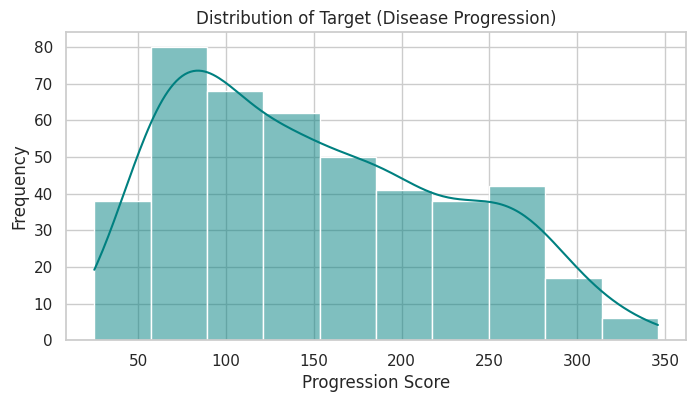

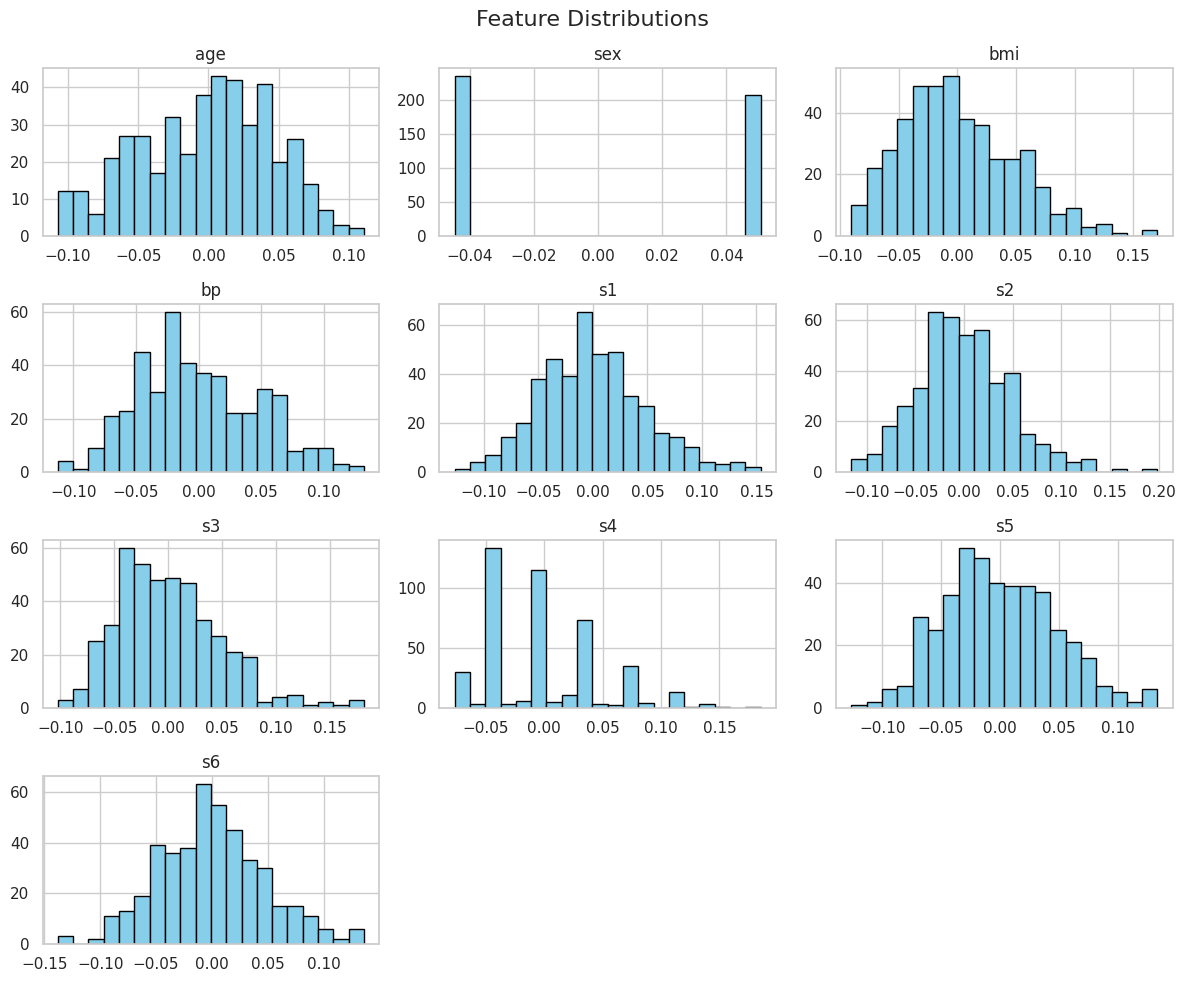

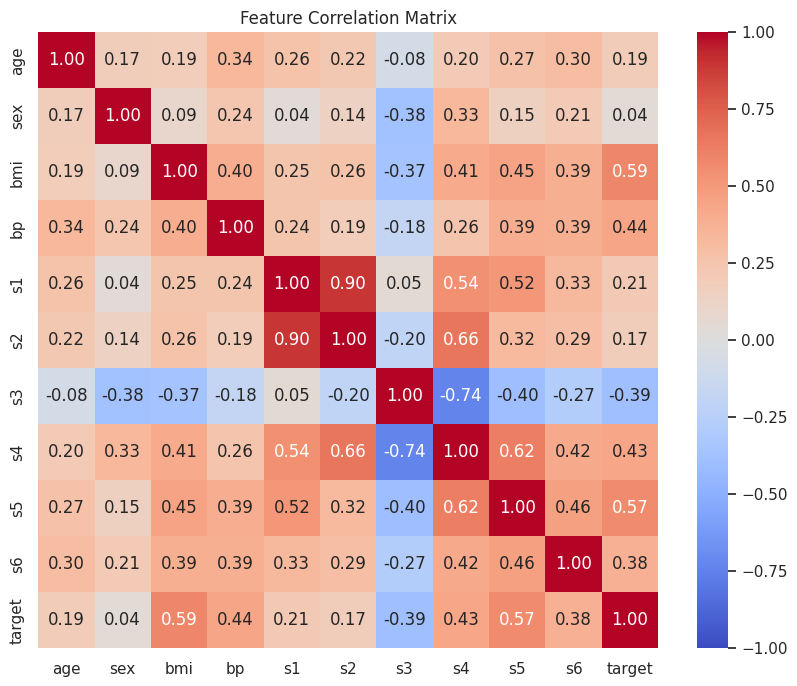

Correlation of features with target:
 bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
Name: target, dtype: float64


In [2]:
# ==========================================
# Component 2: Exploratory Data Analysis (EDA)
# ==========================================
# Set plot style
sns.set_theme(style="whitegrid")

# 1. Distribution of the Target Variable (Diabetes Progression)
plt.figure(figsize=(8, 4))
sns.histplot(y, kde=True, color='teal')
plt.title('Distribution of Target (Disease Progression)')
plt.xlabel('Progression Score')
plt.ylabel('Frequency')
plt.show()

# 2. Distribution of Features
df.drop(columns=['target']).hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.show()

# 4. Feature Relationships with Target Variable
correlations = corr_matrix['target'].drop('target').sort_values(ascending=False)
print("Correlation of features with target:\n", correlations)

3. Building the ANN Model (4 marks)
● Design a simple ANN architecture with at least one hidden layer.
● Use appropriate activation functions .
4. Training the ANN Model (4 marks)
● Split the dataset into training and testing sets.
● Train the model on the training data.
● Use an appropriate loss function and optimizer.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

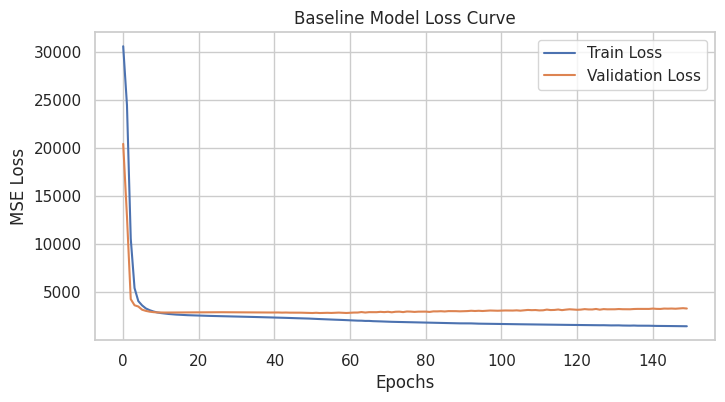

In [3]:
# ==========================================
# Component 3 & 4: Building & Training Baseline ANN Model
# ==========================================
def build_baseline_model(input_dim):
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')  # Regression output
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='mean_squared_error',
        metrics=['mean_squared_error', 'mean_absolute_error']
    )
    return model

baseline_model = build_baseline_model(X_train.shape[1])
baseline_model.summary()

# Train the Baseline Model
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    verbose=0
)

# Plot Loss Curves
plt.figure(figsize=(8, 4))
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

5. Evaluating the Model (3 marks)
● Evaluate the model on the testing data.
● Report the performance metrics (e.g., Mean Squared Error, R2 Score).

In [4]:
# ==========================================
# Component 5: Evaluating the Baseline Model
# ==========================================
y_pred_base = baseline_model.predict(X_test).flatten()

mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)

print("--- Baseline Model Performance ---")
print(f"Mean Squared Error (MSE): {mse_base:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_base:.2f}")
print(f"Mean Absolute Error (MAE): {mae_base:.2f}")
print(f"R² Score: {r2_base:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
--- Baseline Model Performance ---
Mean Squared Error (MSE): 3596.40
Root Mean Squared Error (RMSE): 59.97
Mean Absolute Error (MAE): 48.47
R² Score: 0.3212


6. Improving the Model (5 marks)
○ Experiment with different architectures, activation functions, or
hyperparameters to improve the model performance.
○ Report the changes made and the corresponding improvement in
performance.

In [5]:
# ==========================================
# Component 6: Improving the Model
# ==========================================
# Hyperparameter Optimizations applied:
# 1. Added L2 Regularization & Dropout (to prevent overfitting)
# 2. Adjusted Architecture (64 -> 32 -> 16 neurons)
# 3. Fine-tuned learning rate with Adam optimizer
# 4. Added Early Stopping

def build_improved_model(input_dim):
    model = Sequential([
        Dense(64, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(0.01), input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='swish', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss='mean_squared_error',
        metrics=['mean_squared_error', 'mean_absolute_error']
    )
    return model

improved_model = build_improved_model(X_train.shape[1])

# Callback for early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0
)

# Evaluate Improved Model
y_pred_imp = improved_model.predict(X_test).flatten()

mse_imp = mean_squared_error(y_test, y_pred_imp)
rmse_imp = np.sqrt(mse_imp)
mae_imp = mean_absolute_error(y_test, y_pred_imp)
r2_imp = r2_score(y_test, y_pred_imp)

# Performance Comparison Table
results_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Baseline Model': [mse_base, rmse_base, mae_base, r2_base],
    'Improved Model': [mse_imp, rmse_imp, mae_imp, r2_imp]
})

print("--- Performance Comparison ---")
print(results_df.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
--- Performance Comparison ---
  Metric  Baseline Model  Improved Model
     MSE     3596.397122     2847.176260
    RMSE       59.969969       53.358938
     MAE       48.467300       41.954634
R² Score        0.321198        0.462610
